In [1]:
## load required packages
from dill.temp import b
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print("JAX path:", jax.__file__)

## load module
import sys

bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/project/Elena/BSTPP')
#bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/project/BSTPP')
sys.path.insert(0, bstpp_module_dir)
import bstpp

import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import geopandas as gpd
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
#!pip install torch
import torch
from shapely.geometry import box
import contextily as ctx ## for basemap
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates 
import calendar
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
from shapely.geometry import Point ## for spatial jittering
from sklearn.cluster import DBSCAN
from highlight_text import ax_text, fig_text
import plotly.express as px
import plotly.graph_objects as go

np.random.seed(999)


from bstpp.main import Hawkes_Model

JAX path: /Users/yuxin/miniconda3/lib/python3.12/site-packages/jax/__init__.py


In [2]:
## set working directory
import os
os.chdir("/Users/yuxin/Dropbox/DDDI/Illegal-Dumping")

## Processing response time

### Loadding illegal dumping data

In [3]:
# ## read the geojson file
# illegal_dumping = gpd.read_file('output/illegal_dumping_21_24.geojson')

# ## load 2025 data
# litter_25 = gpd.read_file('data/311/2025/public_cases_fc.shp')
# ## filter data
# illegal_dumping_25 = litter_25[litter_25['service_na'] == "Illegal Dumping"]
# illegal_dumping_25 = illegal_dumping_25.to_crs(epsg=26918)

# ## concact with 2025 data
# illegal_dumping = pd.concat([illegal_dumping, illegal_dumping_25])

# ## filter 2023 and 2024 data for test
# #illegal_dumping_23_24 = illegal_dumping[illegal_dumping['requested_'] >= '2023-01-01']

# ## drop invalid geometry
# illegal_dumping = illegal_dumping[illegal_dumping.geometry.notnull()].copy()

# ## drop irrelavent columns
# illegal_dumping = illegal_dumping.drop(columns=['media_url','lat', 'lon','agency_res', 'service_co','status_not'])

### Computing response and report time 

In [4]:
# ## location aggregation
# # round to nearest multiple of 10
# illegal_dumping['x_round'] = (illegal_dumping.geometry.x / 10).round() * 10
# illegal_dumping['y_round'] = (illegal_dumping.geometry.y / 10).round() * 10

# # nre xy coords column
# illegal_dumping['xy_round'] = list(zip(illegal_dumping['x_round'], illegal_dumping['y_round']))

# # drop x_round and y_round
# illegal_dumping = illegal_dumping.drop(columns=['x_round', 'y_round'])

In [5]:
## computing response time: between closed_date and requested_date
# illegal_dumping['response_time'] = illegal_dumping['closed_dat'] - illegal_dumping['requested_']

In [6]:
# # Make a copy to avoid modifying the original
# df = illegal_dumping.copy()
# df['requested_'] = pd.to_datetime(df['requested_'])
# df['closed_dat'] = pd.to_datetime(df['closed_dat'])

# # Rename closed_dat to prev_closed for clarity
# df = df.rename(columns={'closed_dat': 'prev_closed'})

# # Self-join on xy_round to find next request after each prev_closed
# future_requests = (
#     df[['xy_round', 'requested_', 'prev_closed']]
#     .merge(
#         df[['xy_round', 'requested_']].rename(columns={'requested_': 'next_request'}),
#         on='xy_round',
#         how='left'
#     )
# )

# # Keep only where next_request happens after this row's prev_closed
# future_requests = future_requests[future_requests['next_request'] > future_requests['prev_closed']]

# # Sort and keep only the first such request per original record (xy_round + prev_closed)
# future_requests = (
#     future_requests
#     .sort_values('next_request')
#     .groupby(['xy_round', 'prev_closed'], as_index=False)
#     .first()  # This keeps next_request
# )

# # Merge next_request back to original df
# df = df.merge(future_requests[['xy_round', 'prev_closed', 'next_request']], on=['xy_round', 'prev_closed'], how='left')

# # Calculate delta
# df['delta_t'] = df['next_request'] - df['prev_closed']
# df['delta_t_days'] = df['delta_t'].dt.total_seconds() / (24 * 3600)

In [7]:
# # Step 1: Ensure datetime columns
# df = illegal_dumping.copy()
# df['requested_'] = pd.to_datetime(df['requested_'])
# df['closed_dat'] = pd.to_datetime(df['closed_dat'])

# # Step 2: Prepare all potential (xy_round, prev_closed, requested_) combinations
# df_left = df[['xy_round', 'requested_']].copy()
# df_right = df[['xy_round', 'closed_dat']].copy().rename(columns={'closed_dat': 'prev_closed'})

# # Step 3: Cross join within each xy_round, and filter prev_closed < requested_
# df_prev = (
#     df_left.merge(df_right, on='xy_round', how='left')
#            .query("prev_closed < requested_")
# )

# # Step 4: For each (xy_round, requested_), pick the latest prev_closed
# df_prev = (
#     df_prev.sort_values(['xy_round', 'requested_', 'prev_closed'])
#            .drop_duplicates(['xy_round', 'requested_'], keep='last')
# )

# # Step 5: Merge back to original df to assign prev_closed
# df = df.merge(df_prev, on=['xy_round', 'requested_'], how='left')

# # Step 6: Avoid self-matches (if any)
# df.loc[df['prev_closed'] == df['closed_dat'], 'prev_closed'] = pd.NaT

# # Step 7: Find next_request after prev_closed (your original logic)
# future_requests = (
#     df[['xy_round', 'requested_', 'prev_closed']]
#     .merge(df[['xy_round', 'requested_']].rename(columns={'requested_': 'next_request'}),
#            on='xy_round', how='left')
# )

# # Only keep future requests after this row’s prev_closed
# future_requests = future_requests[future_requests['next_request'] > future_requests['prev_closed']]

# # Sort and keep the first next request per (xy_round, prev_closed)
# future_requests = (
#     future_requests.sort_values('next_request')
#                    .groupby(['xy_round', 'prev_closed'], as_index=False)
#                    .first()
# )

# # Step 8: Merge back next_request to main df
# df = df.merge(future_requests[['xy_round', 'prev_closed', 'next_request']],
#               on=['xy_round', 'prev_closed'], how='left')

# # Step 9: Calculate deltas
# df['delta_t'] = df['next_request'] - df['prev_closed']
# df['delta_t_days'] = df['delta_t'].dt.total_seconds() / (24 * 3600)



In [8]:
# sns.histplot(x=df['delta_t_days'], bins=100)
# plt.yscale('log')
# plt.xlabel("delta_t_days")
# plt.ylabel("Log Count")
# plt.title("Histogram of delta_t_days (log-scaled count)")

In [9]:
# fig, ax = plt.subplots(figsize=(5, 5))
# df_map = df.copy()
# df_map[(df_map['requested_'] >= '2022-01-01') & (df_map['requested_'] <= '2023-01-01')].plot(ax=ax, column = 'delta_t_days',cmap = 'viridis', markersize=10, alpha=0.5)

### Time series

In [10]:
# # Sort by location and time
# df = df.sort_values(['xy_round', 'requested_'])

# # Function to calculate accumulated count between cleanups for each location
# def accumulate_counts(group):
#     group = group.copy()
#     count = 0
#     last_close = None
    
#     for i, row in group.iterrows():
#         # If we see a cleanup date later than the last one, reset
#         if pd.notnull(row['prev_closed']) and (last_close is None or row['prev_closed'] > last_close):
#             last_close = row['prev_closed']
#             count = 0
#         count += 1
#         group.at[i, 'accum_count'] = count
#     return group

# # Apply per location
# df = df.groupby('xy_round', group_keys=False).apply(accumulate_counts)

# # Sum accumulation across all locations per day
# daily_counts = (
#     df.groupby('requested_', as_index=False)['accum_count']
#       .sum()
# )

In [11]:

# # Plot zoomed-in period
# plt.figure(figsize=(12,6))
# plt.plot(daily_counts['requested_'], daily_counts['accum_count'], label='Accumulated Reports')
# plt.xlabel('Date')
# plt.ylabel('Number of Reports Since Last Cleanup (All Locations)')
# plt.title('Accumulation of Illegal Dumping Reports ')
# plt.legend()
# plt.show()

In [12]:
# # Filter for 2021
# mask = (daily_counts['requested_'] >= '2025-04-01') & (daily_counts['requested_'] <= '2025-05-01')
# daily_counts_2021 = daily_counts.loc[mask]

# # Plot zoomed-in period
# plt.figure(figsize=(12,6))
# plt.plot(daily_counts_2021['requested_'], daily_counts_2021['accum_count'], label='Accumulated Reports')
# plt.xlabel('Date')
# plt.ylabel('Number of Reports Since Last Cleanup (All Locations)')
# plt.title('Accumulation of Illegal Dumping Reports (2021)')
# plt.legend()
# plt.show()


In [13]:
# # Unique cleanup dates only
# cleanup_dates_unique = (
#     pd.to_datetime(df['prev_closed'])
#       .dropna()
#       .dt.normalize()  # remove time part
#       .drop_duplicates()  # one per date
#       .sort_values()
# )

# # Filter for zoomed range
# cleanup_dates_unique = cleanup_dates_unique[
#     (cleanup_dates_unique >= '2025-04-01') & (cleanup_dates_unique <= '2025-05-01')
# ]

# # Plot with unique cleanup dates
# plt.figure(figsize=(12,6))
# plt.plot(daily_counts_2021['requested_'], daily_counts_2021['accum_count'], label='Accumulated Reports')

# for date in cleanup_dates_unique:
#     plt.axvline(x=date, color='red', linestyle='--', alpha=0.5)

# plt.xlabel('Date')
# plt.ylabel('Number of Reports Since Last Cleanup (All Locations)')
# plt.title('Accumulation of Illegal Dumping Reports (2021) with Cleanup Dates')
# plt.legend()
# plt.show()




In [14]:
# # Step 1: Pick one xy_round
# chosen_loc = df['xy_round'].value_counts().idxmax()  # most frequent
# # or manually: chosen_loc = (486900.0, 4419880.0)

# # Step 2: Filter
# df_one = df[df['xy_round'] == chosen_loc].copy()
# df_one = df_one.sort_values('requested_')

# # Step 3: Compute accumulation
# count = 0
# last_close = None
# accum_list = []

# for i, row in df_one.iterrows():
#     if pd.notnull(row['prev_closed']) and (last_close is None or row['prev_closed'] > last_close):
#         last_close = row['prev_closed']
#         count = 0
#     count += 1
#     accum_list.append(count)

# df_one['accum_count'] = accum_list

# # Filter for 2021 to 2022
# df_one_zoomed = df_one[
#     (df_one['requested_'] >= '2024-06-01') &
#     (df_one['requested_'] <= '2024-08-01')
# ]

# # Step 4: Plot
# plt.figure(figsize=(12,6))
# plt.plot(df_one_zoomed['requested_'], df_one_zoomed['accum_count'], label='Accumulated Reports')

# # Add vertical lines for prev_closed during this period
# for date in df_one_zoomed['prev_closed'].dropna().unique():
#     plt.axvline(x=date, color='red', linestyle='--', alpha=0.7)

# plt.xlabel('Date')
# plt.ylabel('Accumulated Reports Since Cleanup')
# plt.title(f'Accumulated Illegal Dumping Reports at Location {chosen_loc} (2021)')
# plt.legend()
# plt.show()


In [15]:
# # 1. Pick one xy_round
# chosen_loc = df['xy_round'].value_counts().idxmax()

# # 2. Filter to that location
# df_one = df[df['xy_round'] == chosen_loc].copy()

# # 3. Floor each report to its date
# df_one['request_date'] = df_one['requested_'].dt.floor('D')

# # 4. Build a complete date index from min to max
# full_dates = pd.date_range(
#     start=df_one['request_date'].min(),
#     end=df_one['request_date'].max(),
#     freq='D'
# )

# # 5. Count reports per day, reindex to include empty days
# daily_counts = (
#     df_one
#     .groupby('request_date')
#     .size()
#     .rename('daily_count')
#     .reindex(full_dates, fill_value=0)
#     .rename_axis('request_date')
#     .reset_index()
# )

# # 6. Compute the 3-day rolling average on that daily series
# daily_counts['rolling_avg_3day'] = (
#     daily_counts['daily_count']
#     .rolling(window=3, center=True, min_periods=1)
#     .mean()
# )

# # 7. Optionally, merge back the nearest cleanup date for each day
# #    (so you can still draw vertical cleanup lines)
# #    We take, for each cleanup datetime, its date floor.
# cleanup_dates = (
#     df_one['prev_closed']
#     .dropna()
#     .dt.floor('D')
#     .drop_duplicates()
# )

# # 8. Zoom to your plotting window
# start, end = '2024-06-01', '2024-08-01'
# mask = (daily_counts['request_date'] >= start) & (daily_counts['request_date'] <= end)
# plot_df = daily_counts[mask]

# # 9. Plot
# plt.figure(figsize=(12, 6))
# plt.plot(
#     plot_df['request_date'],
#     plot_df['rolling_avg_3day'],
#     label='3-Day Rolling Avg',
#     linewidth=2
# )

# # 10. Add cleanup lines (floored to date)
# for d in cleanup_dates:
#     if start <= str(d) <= end:
#         plt.axvline(d, color='red', linestyle='--', alpha=0.6)

# plt.xlabel('Date')
# plt.ylabel('Avg Daily Reports (3-Day Window)')
# plt.title(f'3-Day Rolling Average of Reports at Location {chosen_loc}')
# plt.legend()
# plt.tight_layout()
# plt.show()


In [16]:
# # Step 1: Pick one xy_round
# chosen_loc = df['xy_round'].value_counts().idxmax()
# # or manually: chosen_loc = (486900.0, 4419880.0)

# # Step 2: Filter and sort
# df_one = df[df['xy_round'] == chosen_loc].copy()
# df_one = df_one.sort_values('requested_')

# # Step 3: Compute accumulation since last cleanup
# count = 0
# last_close = None
# accum_list = []

# for i, row in df_one.iterrows():
#     if pd.notnull(row['prev_closed']) and (last_close is None or row['prev_closed'] > last_close):
#         last_close = row['prev_closed']
#         count = 0
#     count += 1
#     accum_list.append(count)

# df_one['accum_count'] = accum_list

# # Step 4: Add a request_date column
# df_one['request_date'] = df_one['requested_'].dt.floor('D')

# # Step 5: Create full calendar of dates in the range
# full_dates = pd.date_range(
#     start=df_one['request_date'].min(),
#     end=df_one['request_date'].max(),
#     freq='D'
# )

# # Step 6: Aggregate daily report counts and reindex to include all dates
# daily_counts = (
#     df_one.groupby('request_date')
#           .size()
#           .rename('daily_count')
#           .reindex(full_dates, fill_value=0)
#           .rename_axis('request_date')
#           .reset_index()
# )

# # Step 7: Calculate rolling average over actual date index
# daily_counts['rolling_avg_3day'] = (
#     daily_counts['daily_count']
#     .rolling(window=3, center=True, min_periods=1)
#     .mean()
# )

# # Step 8: Merge rolling average back to df_one by calendar date
# df_plot = df_one.merge(daily_counts, on='request_date', how='left')

# # Step 9: Filter for plotting window
# df_plot = df_plot[
#     (df_plot['request_date'] >= '2024-06-01') &
#     (df_plot['request_date'] <= '2024-08-01')
# ].copy()


# # Step 9.5 (Fixed): Ensure unique dates by aggregating before reindexing
# df_plot_agg = (
#     df_plot.groupby('request_date', as_index=False)['rolling_avg_3day']
#     .sum()  # or .mean(), depending on your goal
# )

# # Create full calendar range
# full_date_range = pd.date_range(
#     start=df_plot_agg['request_date'].min(),
#     end=df_plot_agg['request_date'].max(),
#     freq='D'
# )

# # Reindex to full calendar with 0 for missing values
# df_plot_full = (
#     df_plot_agg.set_index('request_date')
#     .reindex(full_date_range)
#     .fillna({'rolling_avg_3day': 0})
#     .rename_axis('request_date')
#     .reset_index()
# )

# # Step 10: Plot
# plt.figure(figsize=(12, 6))
# plt.plot(
#     df_plot_full['request_date'],
#     df_plot_full['rolling_avg_3day'],
#     label='3-Day Rolling Avg',
#     color='blue'
# )

# # Step 11: Add cleanup vertical lines
# for date in df_one['prev_closed'].dropna().dt.floor('D').unique():
#     if df_plot_full['request_date'].min() <= date <= df_plot_full['request_date'].max():
#         plt.axvline(x=date, color='red', linestyle='--', alpha=0.7)

# plt.xlabel('Date')
# plt.ylabel('3-Day Rolling Avg of Reports')
# plt.title(f'3-Day Rolling Average of Illegal Dumping Reports at Location {chosen_loc}')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()



In [17]:
# # Ensure datetime types
# df['requested_'] = pd.to_datetime(df['requested_'])
# df['closed_dat'] = pd.to_datetime(df['closed_dat'])

# # Filter within date range
# start_date = pd.to_datetime("2024-06-01")
# end_date = pd.to_datetime("2025-01-01")
# df_filtered = df[(df['requested_'] >= start_date) & (df['requested_'] <= end_date)]

# # Find the most frequent xy_round
# most_common_xy = df_filtered['xy_round'].mode().iloc[0]

# # Keep only rows with the most frequent xy_round
# df_xy = df_filtered[df_filtered['xy_round'] == most_common_xy].copy()

# # Sort by requested_ for plotting
# df_xy = df_xy.sort_values('requested_').reset_index(drop=True)

# # Plotting
# fig, ax = plt.subplots(figsize=(15, 6))

# # Dumbbell lines
# ax.hlines(y=df_xy.index, xmin=df_xy['requested_'], xmax=df_xy['closed_dat'], color='gray', alpha=0.7)

# # Start (requested_) dots
# ax.plot(df_xy['requested_'], df_xy.index, "o", label="Requested", color='blue')

# # End (closed_dat) dots
# ax.plot(df_xy['closed_dat'], df_xy.index, "o", label="Closed", color='green')

# # Add vertical lines at each closed_dat
# for date in df_xy['closed_dat']:
#     ax.axvline(date, color='green', linestyle='--', linewidth=0.5, alpha=0.6)

# # Format x-axis as dates
# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
# plt.xticks(rotation=45)

# # Labels and title
# ax.set_xlabel("Date")
# ax.set_ylabel("Service Request Index")
# ax.set_title(f"Illegal Dumping Requests for Most Common Location {most_common_xy}")
# ax.legend()
# plt.tight_layout()


# plt.savefig('output/dumbell_most.png', dpi=500, bbox_inches='tight')
# plt.show()

## Full 311 case report rate/ trash appearing rate

### Clustering reports by address

In [18]:
## loadding full 311 data
full_report = gpd.read_file('output/illegal_dumping_full.geojson')

In [19]:
## print the number of unique address
print("Total number of cases: ", full_report.shape[0])
print("Number of unique addresses: ", len(full_report["address"].unique()))

Total number of cases:  127598
Number of unique addresses:  59551


### Plotting time series for the most appearing address

In [20]:
# Data Processing
# ===============

# Read the data
df = full_report.copy()

# Convert time columns to datetime
df['start_time'] = pd.to_datetime(df['start_time'])
df['close_time'] = pd.to_datetime(df['close_time'])

# Filter data to time range (2025-01-01 to 2025-08-01)
start_date = pd.to_datetime('2024-01-01')
end_date = pd.to_datetime('2025-01-01')

df = df[
    (df['start_time'] >= start_date) & 
    (df['start_time'] <= end_date) 
]

# Define outlier mask: gap > 120 days ------------------------------
outlier = (df['close_time'] - df['start_time']).dt.days > 120

# Remove outliers
df = df[~outlier]

# Find most frequent address
most_frequent_address = df['address'].value_counts().index[0]
print(f"Most frequent address: {most_frequent_address}")

# Filter data for the most frequent address
data = df[df['address'] == most_frequent_address].sort_values('start_time')

# Reset index for plotting
data = data.reset_index(drop=True)


Most frequent address: 1800 WASHINGTON AVE


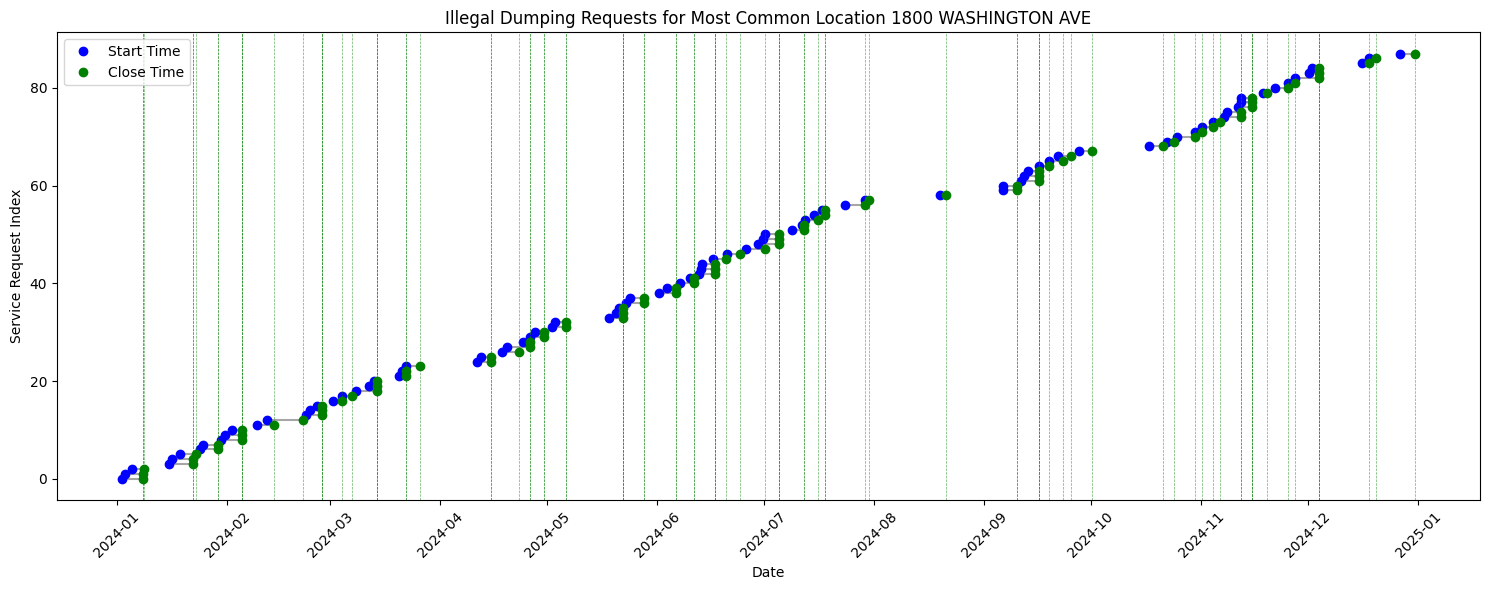

In [21]:
# Plotting
fig, ax = plt.subplots(figsize=(15, 6))

# Dumbbell lines
ax.hlines(y=data.index, xmin=data['start_time'], xmax=data['close_time'], color='gray', alpha=0.7)

# Start (start_time) dots
ax.plot(data['start_time'], data.index, "o", label="Start Time", color='blue')

# End (close_time) dots
ax.plot(data['close_time'], data.index, "o", label="Close Time", color='green')

# Add vertical lines at each closed_dat
for date in data['close_time']:
    ax.axvline(date, color='green', linestyle='--', linewidth=0.5, alpha=0.6)

# Format x-axis as dates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

# Labels and title
ax.set_xlabel("Date")
ax.set_ylabel("Service Request Index")
ax.set_title(f"Illegal Dumping Requests for Most Common Location {most_frequent_address}")
ax.legend()
plt.tight_layout()


plt.savefig('output/dumbell_most_address(24-25).png', dpi=500, bbox_inches='tight')
plt.show()

### Plotting close rate

In [22]:
# # For cases that share the same close_time, keep only the one with earliest start_time

# data_filtered = data.groupby('close_time')['start_time'].min().reset_index()
# data_filtered = data_filtered.sort_values('start_time')

# # Reset index for plotting
# data_filtered = data_filtered.reset_index(drop=True)

# print(f"Original cases: {len(data)}, Filtered cases: {len(data_filtered)}")


In [23]:
# For cases that share the same close_time, keep only the one with earliest start_time
data_filtered = (data.sort_values(['close_time','start_time'])
                    .drop_duplicates(subset='close_time', keep='first')
                    .reset_index(drop=True))

print(f"Original cases: {len(data)}, Filtered cases: {len(data_filtered)}")

Original cases: 88, Filtered cases: 57


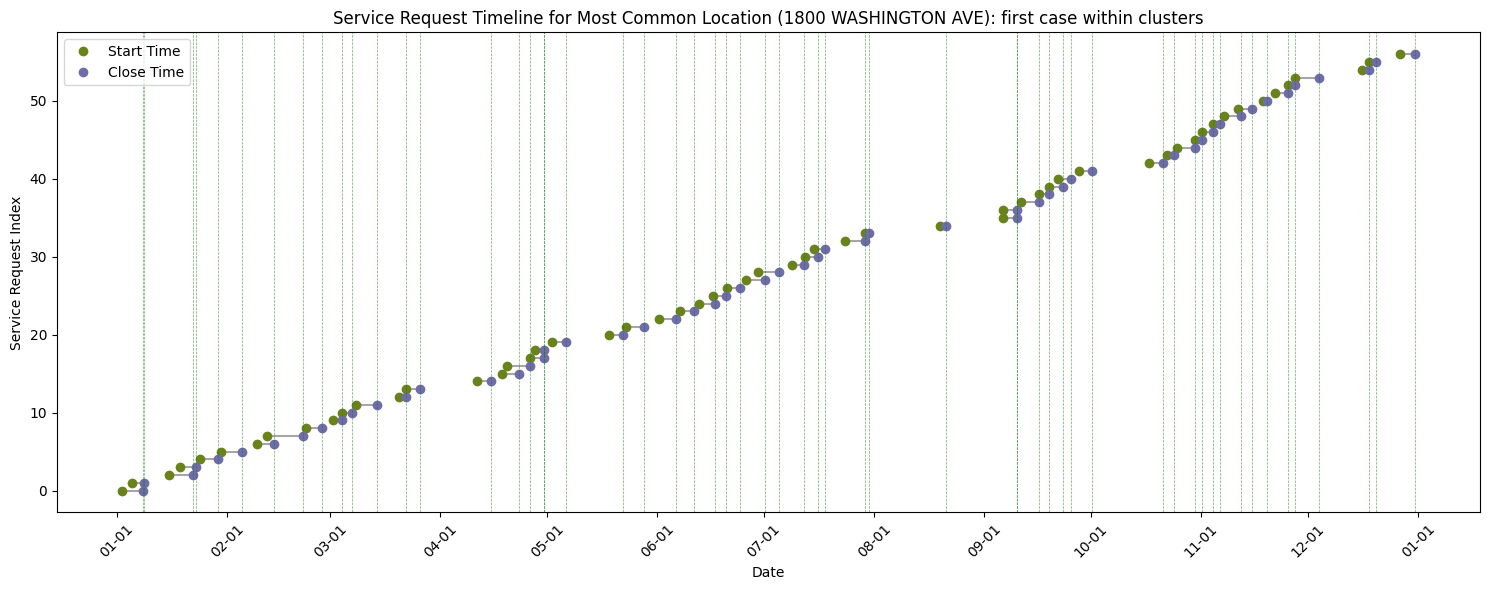

In [24]:
fig, ax = plt.subplots(figsize=(15, 6))

# Dumbbell lines
ax.hlines(y=data_filtered.index, xmin=data_filtered['start_time'], xmax=data_filtered['close_time'], color='gray', alpha=0.7)

# Start (start_time) dots
ax.plot(data_filtered['start_time'], data_filtered.index, "o", label="Start Time", color='#69821b')

# End (close_time) dots
ax.plot(data_filtered['close_time'], data_filtered.index, "o", label="Close Time", color='#706caa')

# Add vertical lines at each close_time
for date in data_filtered['close_time']:
    ax.axvline(date, color='green', linestyle='--', linewidth=0.5, alpha=0.6)

# Format x-axis as dates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.xticks(rotation=45)

# Labels and title
ax.set_xlabel('Date')
ax.set_ylabel('Service Request Index')
ax.set_title(f"Service Request Timeline for Most Common Location ({most_frequent_address}): first case within clusters")
ax.legend()
plt.tight_layout()

plt.savefig('output/dumbbell_most_address_first_case.png', dpi=300, bbox_inches='tight')
plt.show()

### Plotting Inter-arrival distribution

Mean gap (days): 5.875
Median gap (days): 5.0
Std dev (days): 5.222547271207796


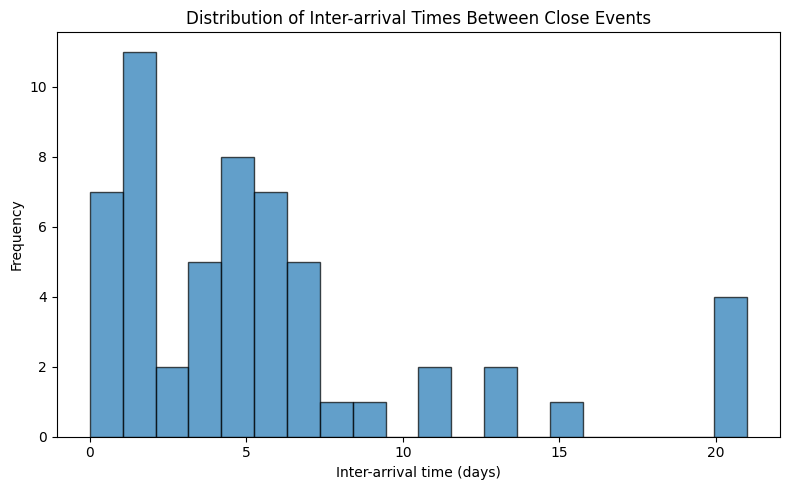

In [25]:
# Make sure data is sorted by close_time
data_filtered = data_filtered.sort_values('close_time').reset_index(drop=True)

# Calculate inter-arrival times in days
inter_arrival = data_filtered['close_time'].diff().dt.days.dropna()

# Summary stats
print("Mean gap (days):", inter_arrival.mean())
print("Median gap (days):", inter_arrival.median())
print("Std dev (days):", inter_arrival.std())

# Histogram of inter-arrival distribution
plt.figure(figsize=(8,5))
plt.hist(inter_arrival, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel("Inter-arrival time (days)")
plt.ylabel("Frequency")
plt.title("Distribution of Inter-arrival Times Between Close Events")
plt.tight_layout()
plt.show()

## 311 Data with cluster and order information

Two new columns added:
- cluster_id: a unique id for each clusters
- cluster_seq: the sequential cluster index for each address, in time order
- order_in_cluster: the order index of a particular report within its cluster
- close_time_window: set 10-min window for each close_time

In [26]:
# Set for the entire session
pd.set_option('display.max_colwidth', None)

# To reset back to default later:
#pd.reset_option('display.max_colwidth')

In [27]:
outlier.shape

(26554,)

In [28]:
df = full_report.copy()
# Define outlier mask: gap > 120 days ------------------------------
outlier = (df['close_time'] - df['start_time']).dt.days > 120
# Count outliers
num_outliers = outlier.sum()

# Remove outliers
df = df[~outlier]
print("Number of outliers removed:", num_outliers)

df['close_time'] = pd.to_datetime(df['close_time'], errors='coerce')

# Sort so diffs are meaningful
df = df.sort_values(['address', 'close_time']).reset_index(drop=True)

# --- cluster by ADDRESS only, using a 10-minute window on close_time ---
addr_key = df['address'].astype('string').fillna('__NA_ADDR__')

gap = df.groupby(addr_key)['close_time'].diff()
is_new_cluster = gap.isna() | gap.gt(pd.Timedelta(minutes=10)) | df['close_time'].isna()

# cluster number within each address (nullable int for safety)
df['cluster_num'] = is_new_cluster.groupby(addr_key).cumsum().astype('Int64')

# earliest close_time in cluster
df['close_time_window'] = df.groupby([addr_key, 'cluster_num'])['close_time'].transform('min')

# 0-based order within cluster
df['order_in_cluster'] = df.groupby([addr_key, 'cluster_num']).cumcount().astype('Int64')

# --- ordinal of cluster within the ADDRESS (no year involved) ---
cluster_keys = (
    df[['address', 'cluster_num', 'close_time_window']]
      .drop_duplicates()
      .sort_values(['address', 'close_time_window'])
)
cluster_keys['cluster_seq'] = (
    cluster_keys.groupby('address').cumcount() + 1
).astype('Int64')

# map back to all rows
df = df.merge(
    cluster_keys[['address', 'cluster_num', 'close_time_window', 'cluster_seq']],
    on=['address', 'cluster_num', 'close_time_window'],
    how='left'
)

# --- cluster_id without year ---
addr_clean = df['address'].fillna('__NA_ADDR__').astype(str).str.replace(r'\s+', '', regex=True)
seq_str   = df['cluster_seq'].astype('Int64').astype(str).str.zfill(3)

df['cluster_id'] = "IDillegalDumping_" + addr_clean + "_" + seq_str

df = df.drop(columns=['cluster_num'])


Number of outliers removed: 7090


In [29]:
#df.to_file('output/illegal_dumping_clustered.geojson', driver='GeoJSON')

In [30]:
## filter the first case within each cluster
illegal_dumping_first_cases = df[df['order_in_cluster'] == 0]

## export the dataset
#illegal_dumping_first_cases.to_file('output/illegal_dumping_first_cases.geojson', driver='GeoJSON')

###  Example for slides

In [31]:
## get the most common cluster as the example
mst_common_cluster = "IDillegalDumping_1700NNEWKIRKST_008"

## filter the most common cluster
mst_df = df[df['cluster_id'] == mst_common_cluster]

In [32]:
mst_df.head()

,start_time,close_time,request_id,type,department,address,zipcode,status,problem_category,problem,...,lon,case_id,parent_case_id,media_url,year,geometry,close_time_window,order_in_cluster,cluster_seq,cluster_id
20605,2023-05-09 15:49:00,2023-05-16 13:39:00,15890150,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002B6si6,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_973e133ca581f0e6c4ffaa8c1cfed1e8,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,0,8,IDillegalDumping_1700NNEWKIRKST_008
20606,2023-05-08 08:39:00,2023-05-16 13:39:00,15884565,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002B6CVH,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_62b92e8130d98cefbf6c348d0fb99ff4,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,1,8,IDillegalDumping_1700NNEWKIRKST_008
20607,2023-04-26 10:21:00,2023-05-16 13:39:00,15850842,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002AYyXC,5008Y00002AY6eA,None,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,2,8,IDillegalDumping_1700NNEWKIRKST_008
20608,2023-05-13 18:38:00,2023-05-16 13:39:00,15901005,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002BXehI,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_da1c5629deb7453298210a4749e1dac8,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,3,8,IDillegalDumping_1700NNEWKIRKST_008
20609,2023-04-16 09:36:00,2023-05-16 13:39:00,15828540,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002AVZgE,5008Y000029r3yl,None,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,4,8,IDillegalDumping_1700NNEWKIRKST_008


In [33]:
df['cluster_id'].value_counts().head(10)

cluster_id
IDillegalDumping_2836SANDYFORDAVE_008          27
IDillegalDumping_COBBSCREEKPKWY&S59THST_007    21
IDillegalDumping_2834SANDYFORDAVE_011          20
IDillegalDumping_2810SANDYFORDAVE_004          18
IDillegalDumping_7600LEXINGTONAVE_024          15
IDillegalDumping_1700NNEWKIRKST_008            14
IDillegalDumping_5661N5THST_015                13
IDillegalDumping_2832SANDYFORDAVE_007          13
IDillegalDumping_4020MARKETST_001              13
IDillegalDumping_LARCHWOODAVE&S52NDST_011      13
Name: count, dtype: int64

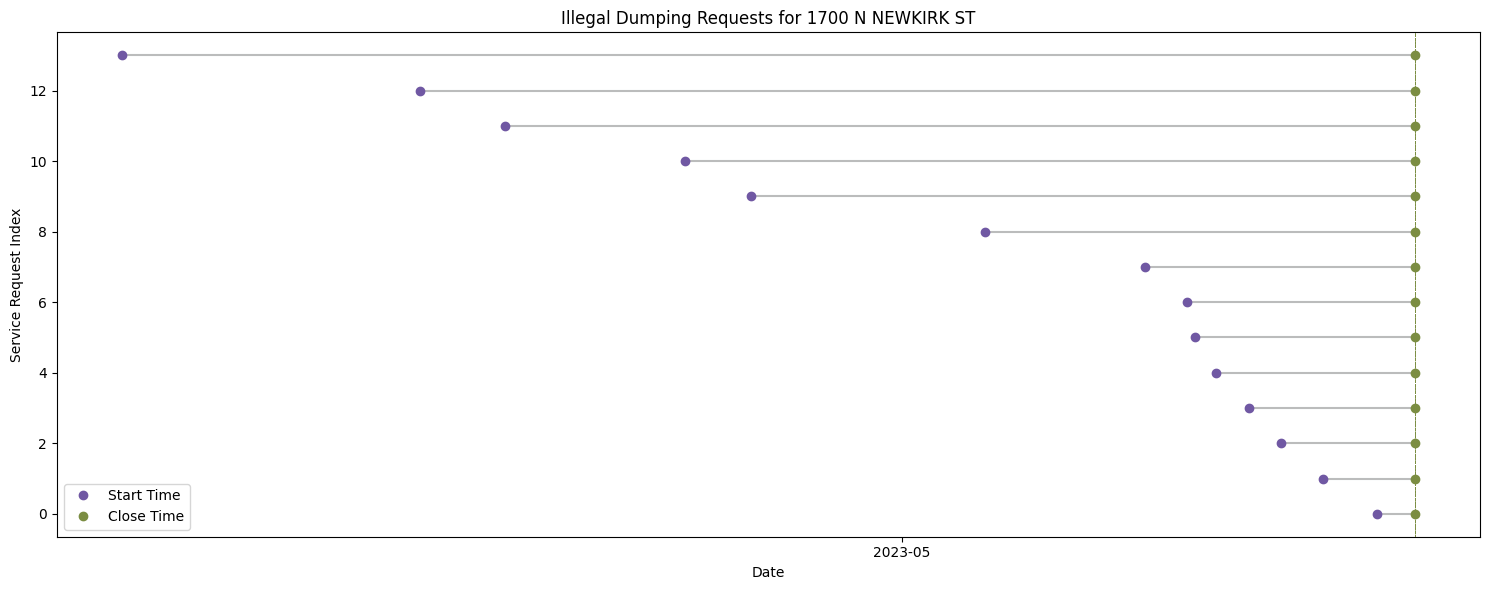

In [34]:
## sort by start_time
mst_df = mst_df.sort_values('start_time', ascending = False).reset_index(drop=True)

# Plotting
fig, ax = plt.subplots(figsize=(15, 6))

# Dumbbell lines
ax.hlines(y=mst_df.index, xmin=mst_df['start_time'], xmax=mst_df['close_time'], color='#9fa0a0', alpha=0.7)

# Start (start_time) dots
ax.plot(mst_df['start_time'], mst_df.index, "o", label="Start Time", color='#7058a3')

# End (close_time) dots
ax.plot(mst_df['close_time'], mst_df.index, "o", label="Close Time", color='#7b8d42')

# Add vertical lines at each closed_dat
for date in mst_df['close_time']:
    ax.axvline(date, color='#7b8d42', linestyle='--', linewidth=0.5, alpha=0.6)

# Format x-axis as dates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
#plt.xticks(rotation=45)

# Labels and title
ax.set_xlabel("Date")
ax.set_ylabel("Service Request Index")
ax.set_title(f"Illegal Dumping Requests for 1700 N NEWKIRK ST")
ax.legend()
plt.tight_layout()


plt.savefig('output/dumbell_1700.png', dpi=500, bbox_inches='tight')
plt.show()

In [35]:
mst_df

,start_time,close_time,request_id,type,department,address,zipcode,status,problem_category,problem,...,lon,case_id,parent_case_id,media_url,year,geometry,close_time_window,order_in_cluster,cluster_seq,cluster_id
0,2023-05-15 09:30:00,2023-05-16 13:39:00,15901985,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002BYJGI,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_59ef9bd35b16b332b0cf6f6c40d32afc,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,12,8,IDillegalDumping_1700NNEWKIRKST_008
1,2023-05-13 18:38:00,2023-05-16 13:39:00,15901005,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002BXehI,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_da1c5629deb7453298210a4749e1dac8,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,3,8,IDillegalDumping_1700NNEWKIRKST_008
2,2023-05-12 12:13:00,2023-05-16 13:39:00,15899161,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002BTGlx,5008Y00002B4j5e,https://d17aqltn7cihbm.cloudfront.net/uploads/large_f405dd591aa7a339010bf3b4a499bd43,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,7,8,IDillegalDumping_1700NNEWKIRKST_008
3,2023-05-11 12:28:00,2023-05-16 13:39:00,15896713,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002BSjy4,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_640bbe4a75956d4e301d16350ea62324,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,8,8,IDillegalDumping_1700NNEWKIRKST_008
4,2023-05-10 12:28:00,2023-05-16 13:39:00,15891959,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002B7ALS,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_ee1f2031cc6a43a3ab8d1a328a7d2d3d,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,6,8,IDillegalDumping_1700NNEWKIRKST_008
5,2023-05-09 21:05:00,2023-05-16 13:39:00,15890701,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002B6zaB,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_b550b66ac66677c2ecae8882289b88c5,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,5,8,IDillegalDumping_1700NNEWKIRKST_008
6,2023-05-09 15:49:00,2023-05-16 13:39:00,15890150,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002B6si6,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_973e133ca581f0e6c4ffaa8c1cfed1e8,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,0,8,IDillegalDumping_1700NNEWKIRKST_008
7,2023-05-08 08:39:00,2023-05-16 13:39:00,15884565,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002B6CVH,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_62b92e8130d98cefbf6c348d0fb99ff4,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,1,8,IDillegalDumping_1700NNEWKIRKST_008
8,2023-05-03 12:42:00,2023-05-16 13:39:00,15876536,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002B4j5e,5008Y00002AYyXC,https://d17aqltn7cihbm.cloudfront.net/uploads/large_87bf942e05f70bd66357f6f299399fb5,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,13,8,IDillegalDumping_1700NNEWKIRKST_008
9,2023-04-26 10:21:00,2023-05-16 13:39:00,15850842,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002AYyXC,5008Y00002AY6eA,None,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,2,8,IDillegalDumping_1700NNEWKIRKST_008


In [36]:
# 2. Create the interactive plot
# Create a base figure object
fig = go.Figure()

# Add the start time points
fig.add_trace(go.Scatter(
    x=mst_df['start_time'],
    y=mst_df.index,
    mode='markers',
    marker=dict(color='#7058a3', size=8),
    name='Start Time',
    hoverinfo='text',
    hovertext=
        'Start Time: ' + mst_df['start_time'].dt.strftime('%Y-%m-%d %H:%M:%S') + '<br>' +
        'Close Time: ' + mst_df['close_time'].dt.strftime('%Y-%m-%d %H:%M:%S') + '<br>' +
        'Media URL: ' + mst_df['media_url']
))

# Add the end time points
fig.add_trace(go.Scatter(
    x=mst_df['close_time'],
    y=mst_df.index,
    mode='markers',
    marker=dict(color='#7b8d42', size=8),
    name='Close Time',
    hoverinfo='text',
    hovertext=
        'Start Time: ' + mst_df['start_time'].dt.strftime('%Y-%m-%d %H:%M:%S') + '<br>' +
        'Close Time: ' + mst_df['close_time'].dt.strftime('%Y-%m-%d %H:%M:%S') + '<br>' +
        'Media URL: ' + mst_df['media_url']
))

# Add the lines connecting the points
for i, row in mst_df.iterrows():
    fig.add_shape(
        type='line',
        x0=row['start_time'], y0=i,
        x1=row['close_time'], y1=i,
        line=dict(color='#9fa0a0', width=2)
    )

# 3. Add vertical lines for each closed_time using the correct method
for date in mst_df['close_time']:
    fig.add_shape(
        type="line",
        x0=date, y0=0,
        x1=date, y1=len(mst_df), # Extends the line the full height of the plot
        line=dict(
            color="#7b8d42",
            width=1,
            dash="dot",
        )
    )

# 4. Update layout with titles and labels
fig.update_layout(
    title="Illegal Dumping Requests for 2836 SANDYFORD AVE",
    xaxis_title="Date",
    yaxis_title="Service Request Index",
    yaxis_autorange='reversed',
    showlegend=True,
    hovermode='closest' # This is the key change
)

fig.show()

In [37]:
mst_df

,start_time,close_time,request_id,type,department,address,zipcode,status,problem_category,problem,...,lon,case_id,parent_case_id,media_url,year,geometry,close_time_window,order_in_cluster,cluster_seq,cluster_id
0,2023-05-15 09:30:00,2023-05-16 13:39:00,15901985,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002BYJGI,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_59ef9bd35b16b332b0cf6f6c40d32afc,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,12,8,IDillegalDumping_1700NNEWKIRKST_008
1,2023-05-13 18:38:00,2023-05-16 13:39:00,15901005,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002BXehI,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_da1c5629deb7453298210a4749e1dac8,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,3,8,IDillegalDumping_1700NNEWKIRKST_008
2,2023-05-12 12:13:00,2023-05-16 13:39:00,15899161,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002BTGlx,5008Y00002B4j5e,https://d17aqltn7cihbm.cloudfront.net/uploads/large_f405dd591aa7a339010bf3b4a499bd43,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,7,8,IDillegalDumping_1700NNEWKIRKST_008
3,2023-05-11 12:28:00,2023-05-16 13:39:00,15896713,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002BSjy4,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_640bbe4a75956d4e301d16350ea62324,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,8,8,IDillegalDumping_1700NNEWKIRKST_008
4,2023-05-10 12:28:00,2023-05-16 13:39:00,15891959,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002B7ALS,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_ee1f2031cc6a43a3ab8d1a328a7d2d3d,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,6,8,IDillegalDumping_1700NNEWKIRKST_008
5,2023-05-09 21:05:00,2023-05-16 13:39:00,15890701,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002B6zaB,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_b550b66ac66677c2ecae8882289b88c5,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,5,8,IDillegalDumping_1700NNEWKIRKST_008
6,2023-05-09 15:49:00,2023-05-16 13:39:00,15890150,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002B6si6,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_973e133ca581f0e6c4ffaa8c1cfed1e8,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,0,8,IDillegalDumping_1700NNEWKIRKST_008
7,2023-05-08 08:39:00,2023-05-16 13:39:00,15884565,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002B6CVH,5008Y000029r3yl,https://d17aqltn7cihbm.cloudfront.net/uploads/large_62b92e8130d98cefbf6c348d0fb99ff4,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,1,8,IDillegalDumping_1700NNEWKIRKST_008
8,2023-05-03 12:42:00,2023-05-16 13:39:00,15876536,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002B4j5e,5008Y00002AYyXC,https://d17aqltn7cihbm.cloudfront.net/uploads/large_87bf942e05f70bd66357f6f299399fb5,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,13,8,IDillegalDumping_1700NNEWKIRKST_008
9,2023-04-26 10:21:00,2023-05-16 13:39:00,15850842,Illegal Dumping,Streets Department,1700 N NEWKIRK ST,19121.0,Closed,None,None,...,-75.180842,5008Y00002AYyXC,5008Y00002AY6eA,None,2023.0,POINT (484559.242 4425747.274),2023-05-16 13:39:00,2,8,IDillegalDumping_1700NNEWKIRKST_008
